# Phase 2 — Text Vectorization (Feature Extraction)

**Goal:** Convert the cleaned Persian text into numerical feature matrices.

**Required three methods:**

| Method | Type | Vector | Key idea |
|---|---|---|---|
| `CountVectorizer` | Sparse | high-dim | Raw word / bigram occurrence counts |
| `TF-IDF` | Sparse | high-dim | Count weighted by inverse document frequency |
| `Word2Vec` (mean pooling, trained from scratch) | Dense | 100-dim | Semantic embeddings trained on our corpus |

**Bonus representations** (extra feature sets the model-selection phase can compare):

| Method | Type | Vector | Why |
|---|---|---|---|
| `Word2Vec` (IDF-weighted) | Dense | 100-dim | Rare sentiment words dominate the document vector (≈ SIF) |
| Hybrid `word + char_wb` TF-IDF | Sparse | high-dim | Char n-grams absorb informal Persian spelling / typos |

All feature matrices are saved to `data/processed/` for Phase 3.

In [2]:
import sys, os
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
for p in [REPO_ROOT, os.path.join(REPO_ROOT, 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
from vectorizers import (
    MeanWord2VecVectorizer,
    TfidfWeightedWord2Vec,
    build_word_char_union,
    oov_rate,
)

DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
MODEL_DIR = os.path.join(REPO_ROOT, 'models', 'word2vec')
FIG_DIR   = os.path.join(REPO_ROOT, 'outputs', 'figures')
os.makedirs(MODEL_DIR, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load Processed Data

In [3]:
train_df = pd.read_csv(os.path.join(DATA_PROC, 'train.csv'), encoding='utf-8')
test_df  = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'),  encoding='utf-8')

# Fill any NaN that may have survived
train_df['cleaned'] = train_df['cleaned'].fillna('').astype(str)
test_df['cleaned']  = test_df['cleaned'].fillna('').astype(str)

X_train = train_df['cleaned'].values
X_test  = test_df['cleaned'].values
y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 55,583 | Test: 13,896


## 2. CountVectorizer

The simplest approach: build a vocabulary from the corpus, then represent each document
as a vector of word/bigram **counts**.

**Settings chosen:**
- `max_features=50000` — keeps the 50k most frequent n-grams; caps memory at a sensible level
- `ngram_range=(1, 2)` — includes unigrams *and* bigrams; bigrams capture sentiment phrases
  like `خیلی خوب` (very good) or `اصلا خوب` (not good at all) as single features
- `min_df=2` — discard n-grams that appear in fewer than 2 documents (hapax legomena add
  noise and bloat vocabulary without helping classification)

In [4]:
count_vec = CountVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)

print(f'CountVectorizer vocab size : {len(count_vec.vocabulary_):,}')
print(f'Train matrix shape         : {X_train_count.shape}')
print(f'Test  matrix shape         : {X_test_count.shape}')
print(f'Sparsity                   : {1 - X_train_count.nnz / (X_train_count.shape[0] * X_train_count.shape[1]):.4%}')

CountVectorizer vocab size : 50,000
Train matrix shape         : (55583, 50000)
Test  matrix shape         : (13896, 50000)
Sparsity                   : 99.9466%


In [5]:
# Top 20 most frequent unigrams
feature_names = count_vec.get_feature_names_out()
total_counts  = np.asarray(X_train_count.sum(axis=0)).flatten()
top20_idx     = total_counts.argsort()[::-1][:20]

print('Top 20 most frequent features (CountVectorizer):')
for i, idx in enumerate(top20_idx):
    print(f'  {i+1:>2}. {feature_names[idx]:<20}  count={int(total_counts[idx]):,}')

Top 20 most frequent features (CountVectorizer):
   1. بود                   count=54,509
   2. به                    count=17,616
   3. از                    count=16,876
   4. که                    count=16,805
   5. خیلی                  count=15,770
   6. هم                    count=13,716
   7. غذا                   count=13,085
   8. کیفیت                 count=11,858
   9. خوب                   count=11,002
  10. عالی                  count=10,627
  11. با                    count=10,591
  12. داشت                  count=9,815
  13. سفارش                 count=9,205
  14. کرد                   count=9,038
  15. شد                    count=9,021
  16. ولی                   count=8,318
  17. این                   count=7,897
  18. در                    count=7,652
  19. پیتزا                 count=7,602
  20. داد                   count=7,512


In [6]:
# Save sparse matrix
sp.save_npz(os.path.join(DATA_PROC, 'X_train_count.npz'), X_train_count)
sp.save_npz(os.path.join(DATA_PROC, 'X_test_count.npz'),  X_test_count)
print('CountVectorizer matrices saved.')

CountVectorizer matrices saved.


## 3. TF-IDF

TF-IDF improves on raw counts by **downweighting very common words** (which carry little
discriminative information) and **upweighting rare, informative words**.

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{\text{df}(t)}$$

**Settings chosen:**
- `max_features=50000`, `ngram_range=(1, 2)`, `min_df=2` — same reasoning as CountVectorizer
- `sublinear_tf=True` — applies `tf = 1 + log(tf)` instead of raw count;
  prevents a word repeated 50× from dominating a review's vector vs. one repeated 5×

In [7]:
tfidf_vec = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(f'TF-IDF vocab size  : {len(tfidf_vec.vocabulary_):,}')
print(f'Train matrix shape : {X_train_tfidf.shape}')
print(f'Test  matrix shape : {X_test_tfidf.shape}')
print(f'Sparsity           : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4%}')

TF-IDF vocab size  : 50,000
Train matrix shape : (55583, 50000)
Test  matrix shape : (13896, 50000)
Sparsity           : 99.9466%


In [8]:
# Top 20 by highest mean TF-IDF weight across training documents
tfidf_names   = tfidf_vec.get_feature_names_out()
mean_tfidf    = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top20_tfidf   = mean_tfidf.argsort()[::-1][:20]

print('Top 20 features by mean TF-IDF weight:')
for i, idx in enumerate(top20_tfidf):
    print(f'  {i+1:>2}. {tfidf_names[idx]:<20}  mean_weight={mean_tfidf[idx]:.5f}')

Top 20 features by mean TF-IDF weight:
   1. بود                   mean_weight=0.04089
   2. خیلی                  mean_weight=0.02222
   3. عالی                  mean_weight=0.02048
   4. به                    mean_weight=0.01933
   5. خوب                   mean_weight=0.01805
   6. غذا                   mean_weight=0.01798
   7. کیفیت                 mean_weight=0.01759
   8. از                    mean_weight=0.01745
   9. هم                    mean_weight=0.01601
  10. که                    mean_weight=0.01563
  11. خوب بود               mean_weight=0.01413
  12. با                    mean_weight=0.01332
  13. داشت                  mean_weight=0.01314
  14. ممنون                 mean_weight=0.01275
  15. شد                    mean_weight=0.01265
  16. بسیار                 mean_weight=0.01255
  17. ولی                   mean_weight=0.01216
  18. عالی بود              mean_weight=0.01197
  19. رسید                  mean_weight=0.01195
  20. پیتزا                 mean_weight=0.01192


In [9]:
sp.save_npz(os.path.join(DATA_PROC, 'X_train_tfidf.npz'), X_train_tfidf)
sp.save_npz(os.path.join(DATA_PROC, 'X_test_tfidf.npz'),  X_test_tfidf)
print('TF-IDF matrices saved.')

TF-IDF matrices saved.


## 4. Word2Vec (Trained from Scratch)

Word2Vec learns **dense vector representations** (embeddings) where semantically similar
words are close in vector space.  Unlike CountVectorizer/TF-IDF, it captures meaning:
`خوب` (good) and `عالی` (excellent) would be nearby.

**We train from scratch** on our own corpus (no pretrained model) because:
1. The project specification requires it
2. Food/delivery domain vocabulary (سفارش, تحویل, رستوران) is well represented in 70k reviews

**Document vector strategy:** average all word vectors in a review.  Simple mean works
well for sentiment because emotional signal is distributed across the whole text.

**Settings chosen:**
- `vector_size=100` — appropriate for a 70k corpus; 300d would be underfit
- `sg=1` (Skip-gram) — better than CBOW for smaller corpora and rare words
- `window=5` — context window of 5 words captures local sentiment context
- `min_count=2` — drop words seen fewer than twice (pure noise)
- `epochs=15` — enough passes for convergence without overfitting

In [10]:
# Prepare tokenized corpus (gensim expects list of lists of strings)
tokenized_train = [text.split() for text in X_train]
tokenized_test  = [text.split() for text in X_test]

print(f'Training corpus: {len(tokenized_train):,} documents')
print(f'Sample tokens from doc 0: {tokenized_train[0][:10]}')

Training corpus: 55,583 documents
Sample tokens from doc 0: ['سلام', 'دستم', 'اشتباهی', 'خورد', 'روی', 'ناراضی', 'در', 'صورتیکه', 'از', 'همه']


In [11]:
print('Training Word2Vec... (takes ~30-60 seconds)')

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,          # Skip-gram
    workers=4,
    epochs=15,
    seed=42,
)

print(f'Vocabulary size: {len(w2v_model.wv):,} words')
print(f'Vector size    : {w2v_model.vector_size}')

Training Word2Vec... (takes ~30-60 seconds)
Vocabulary size: 11,888 words
Vector size    : 100


In [12]:
# Save model
w2v_path = os.path.join(MODEL_DIR, 'persian_w2v.model')
w2v_model.save(w2v_path)
print(f'Model saved to {w2v_path}')

Model saved to e:\University\University_Subjects\6th\Computational_Intelligence\Projects\3\NLP-Ensemble\models\word2vec\persian_w2v.model


In [13]:
# Sanity check: most similar words to key sentiment terms
probe_words = ['خوب', 'بد', 'غذا', 'سفارش']
for w in probe_words:
    if w in w2v_model.wv:
        similar = w2v_model.wv.most_similar(w, topn=5)
        sim_str = ', '.join([f'{s[0]}({s[1]:.2f})' for s in similar])
        print(f'  {w}: {sim_str}')
    else:
        print(f'  {w}: NOT in vocabulary')

  خوب: عالی(0.79), عاالی(0.76), حوب(0.74), خوشمره(0.72), خوشمزه(0.71)
  بد: افتضاح(0.76), بدی(0.73), ونپخته(0.72), افتضااح(0.71), بیکیفیت(0.69)
  غذا: غذابا(0.78), غدا(0.77), عذا(0.70), وغذا(0.70), شرد(0.69)
  سفارش: سفر(0.70), سفار(0.70), سفارس(0.69), نوبت(0.63), شفار(0.63)


In [14]:
# OOV diagnostic
train_oov = oov_rate(X_train, w2v_model)
test_oov  = oov_rate(X_test,  w2v_model)
print(f'OOV rate (train): {train_oov:.2%}')
print(f'OOV rate (test) : {test_oov:.2%}')

OOV rate (train): 53.92%
OOV rate (test) : 37.76%


In [15]:
# Transform to document vectors using mean pooling
w2v_transformer = MeanWord2VecVectorizer(model=w2v_model, vector_size=100)

X_train_w2v = w2v_transformer.transform(X_train)
X_test_w2v  = w2v_transformer.transform(X_test)

print(f'W2V train matrix shape: {X_train_w2v.shape}  dtype={X_train_w2v.dtype}')
print(f'W2V test  matrix shape: {X_test_w2v.shape}')

# Check for all-zero rows (fully OOV documents)
zero_docs = (X_train_w2v.sum(axis=1) == 0).sum()
print(f'All-zero document vectors in train: {zero_docs}')

W2V train matrix shape: (55583, 100)  dtype=float32
W2V test  matrix shape: (13896, 100)
All-zero document vectors in train: 1


In [16]:
np.save(os.path.join(DATA_PROC, 'X_train_w2v.npy'), X_train_w2v)
np.save(os.path.join(DATA_PROC, 'X_test_w2v.npy'),  X_test_w2v)
print('Word2Vec matrices saved.')

Word2Vec matrices saved.


### 4b. Word2Vec — IDF-weighted pooling (bonus dense representation)

Plain mean pooling treats every word equally, so high-frequency filler words dilute the
handful of words that actually carry sentiment. **IDF-weighted pooling** scales each word
vector by its inverse document frequency before averaging, so rare, informative words
(`افتضاح`, `عالی`) dominate the document vector. This is the cheap, strong cousin of
Arora's SIF and reliably beats plain mean pooling on short reviews.

The IDF table is learned from **train only** (inside `fit`) and reused on test to avoid
leakage. We keep the plain-mean Word2Vec above as the *required* representation; this is an
extra dense feature set the model-selection phase can compare against.

In [17]:
# IDF-weighted Word2Vec pooling. fit() learns the IDF table from TRAIN text only.
w2v_idf = TfidfWeightedWord2Vec(model=w2v_model, vector_size=100)
w2v_idf.fit(X_train)

X_train_w2v_idf = w2v_idf.transform(X_train)
X_test_w2v_idf  = w2v_idf.transform(X_test)

print(f'IDF-weighted W2V train shape: {X_train_w2v_idf.shape}  dtype={X_train_w2v_idf.dtype}')
print(f'IDF-weighted W2V test  shape: {X_test_w2v_idf.shape}')

zero_docs = (X_train_w2v_idf.sum(axis=1) == 0).sum()
print(f'All-zero document vectors in train: {zero_docs}')

np.save(os.path.join(DATA_PROC, 'X_train_w2v_idf.npy'), X_train_w2v_idf)
np.save(os.path.join(DATA_PROC, 'X_test_w2v_idf.npy'),  X_test_w2v_idf)
print('IDF-weighted Word2Vec matrices saved.')

IDF-weighted W2V train shape: (55583, 100)  dtype=float32
IDF-weighted W2V test  shape: (13896, 100)
All-zero document vectors in train: 1
IDF-weighted Word2Vec matrices saved.


## 4c. Hybrid Word + Character n-gram TF-IDF (bonus sparse representation)

Persian food-delivery reviews are full of informal spelling, elongation, and attached
morphemes (`خووووب`, `نمیکنه`, typos). A word-level vectorizer treats every spelling
variant as a brand-new, unseen feature. **Character n-grams** (`char_wb`, word-boundary
aware) instead see the shared sub-word pieces, so `خوب` / `خووب` / `خوبه` all light up
overlapping features. Concatenating a word TF-IDF with a char TF-IDF via a `FeatureUnion`
is a well-worn, low-risk way to lift a classical SVM a few points on noisy, short text.

**Upgraded sizing (execution_plan_v3, Track A):** `char_max_features` raised
`50k -> 300k` with a wider `char_ngram_range=(2, 5)` — 2-grams catch single-character
substitutions and short affixes that 3-grams miss, and 300k slots let the char side
capture far more of Persian's spelling-variant space without colliding on `max_features`.
`word_max_features` raised `50k -> 100k` and `min_df` raised `2 -> 3` (a stricter document
frequency floor keeps the larger word vocabulary from filling up with near-hapax noise).

This produces one combined sparse matrix. It keeps the required word-level TF-IDF intact as
one half of the union, and is offered as a 4th representation for model selection.

In [18]:
# Word (1,2) + char_wb (2,5) TF-IDF FeatureUnion. fit on TRAIN, transform both.
# Upgraded sizing per execution_plan_v3 Track A: bigger char vocabulary + wider
# char n-gram range absorb more spelling variation; min_df=3 keeps the larger
# word vocabulary from filling with noise.
hybrid_vec = build_word_char_union(
    word_ngram_range=(1, 2),
    char_ngram_range=(2, 5),
    word_max_features=100_000,
    char_max_features=300_000,
    min_df=3,
    sublinear_tf=True,
)

print('Fitting hybrid word+char TF-IDF... (char n-grams take ~2-4 min with the larger vocab)')
X_train_hybrid = hybrid_vec.fit_transform(X_train)
X_test_hybrid  = hybrid_vec.transform(X_test)

print(f'Hybrid train shape : {X_train_hybrid.shape}')
print(f'Hybrid test  shape : {X_test_hybrid.shape}')
print(f'Sparsity           : {1 - X_train_hybrid.nnz / (X_train_hybrid.shape[0]*X_train_hybrid.shape[1]):.4%}')

sp.save_npz(os.path.join(DATA_PROC, 'X_train_hybrid.npz'), X_train_hybrid)
sp.save_npz(os.path.join(DATA_PROC, 'X_test_hybrid.npz'),  X_test_hybrid)
print('Hybrid word+char matrices saved.')

Fitting hybrid word+char TF-IDF... (char n-grams take ~2-4 min with the larger vocab)
Hybrid train shape : (55583, 101119)
Hybrid test  shape : (13896, 101119)
Sparsity           : 99.7875%
Hybrid word+char matrices saved.


## 5. Vectorizer Comparison Summary

A concise look at what each method produces before we plug them into classifiers.

In [19]:
summary = pd.DataFrame([
    {
        'Vectorizer':   'CountVectorizer',
        'Vector type':  'Sparse',
        'Dimensions':   X_train_count.shape[1],
        'Non-zero (train)': X_train_count.nnz,
        'Sparsity':     f'{1 - X_train_count.nnz / (X_train_count.shape[0]*X_train_count.shape[1]):.3%}',
    },
    {
        'Vectorizer':   'TF-IDF',
        'Vector type':  'Sparse',
        'Dimensions':   X_train_tfidf.shape[1],
        'Non-zero (train)': X_train_tfidf.nnz,
        'Sparsity':     f'{1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.3%}',
    },
    {
        'Vectorizer':   'Word2Vec (mean)',
        'Vector type':  'Dense',
        'Dimensions':   X_train_w2v.shape[1],
        'Non-zero (train)': int((X_train_w2v != 0).sum()),
        'Sparsity':     'N/A (dense)',
    },
])

print(summary.to_string(index=False))

     Vectorizer Vector type  Dimensions  Non-zero (train)    Sparsity
CountVectorizer      Sparse       50000           1484862     99.947%
         TF-IDF      Sparse       50000           1484862     99.947%
Word2Vec (mean)       Dense         100           5558200 N/A (dense)


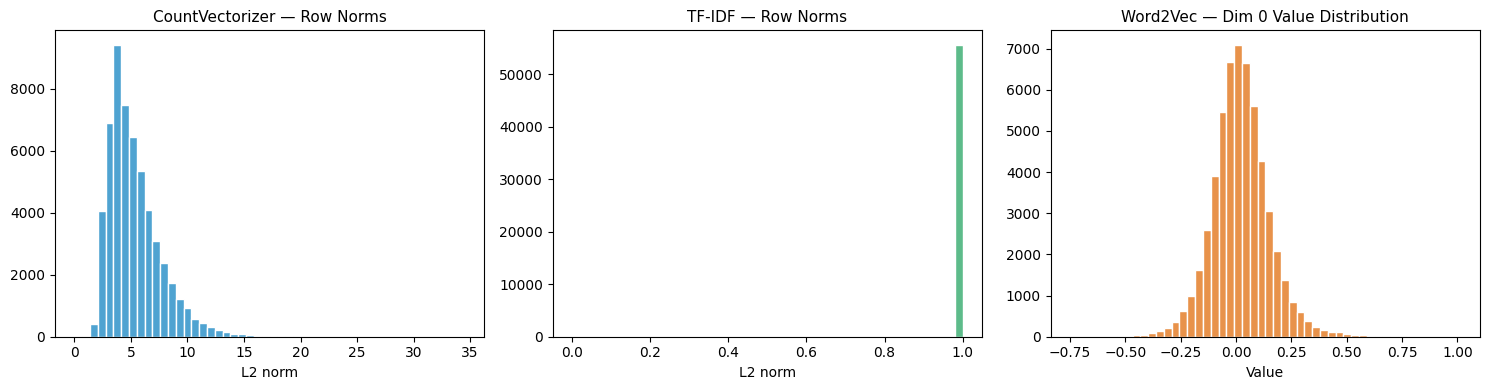

In [20]:
# Visual: distribution of vector norms per vectorizer
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CountVec: row L2 norms
count_norms = np.asarray(X_train_count.power(2).sum(axis=1)).flatten() ** 0.5
axes[0].hist(count_norms, bins=50, color='#4FA3D1', edgecolor='white')
axes[0].set_title('CountVectorizer — Row Norms', fontsize=11)
axes[0].set_xlabel('L2 norm')

# TF-IDF: row L2 norms
tfidf_norms = np.asarray(X_train_tfidf.power(2).sum(axis=1)).flatten() ** 0.5
axes[1].hist(tfidf_norms, bins=50, color='#5DBB8A', edgecolor='white')
axes[1].set_title('TF-IDF — Row Norms', fontsize=11)
axes[1].set_xlabel('L2 norm')

# W2V: distribution of dim 0 values (just to show it's dense and continuous)
axes[2].hist(X_train_w2v[:, 0], bins=50, color='#E8924A', edgecolor='white')
axes[2].set_title('Word2Vec — Dim 0 Value Distribution', fontsize=11)
axes[2].set_xlabel('Value')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'vectorizer_norms.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Summary

| Vectorizer | Dimensions | Sparsity (train) | Type | Saved as |
|---|---|---|---|---|
| CountVectorizer | 50,000 | 99.9466% | Sparse | `X_train_count.npz`, `X_test_count.npz` |
| TF-IDF | 50,000 | 99.9466% | Sparse | `X_train_tfidf.npz`, `X_test_tfidf.npz` |
| Word2Vec (mean) | 100 | N/A (dense) | Dense | `X_train_w2v.npy`, `X_test_w2v.npy` |
| Word2Vec (IDF-weighted) | 100 | N/A (dense) | Dense | `X_train_w2v_idf.npy`, `X_test_w2v_idf.npy` |
| Hybrid word + char TF-IDF | 101,119 | 99.7875% | Sparse | `X_train_hybrid.npz`, `X_test_hybrid.npz` |

The first three are the **required** representations; the last two are bonus feature sets
that Phase 3 / Phase 4 will benchmark to pick the strongest representation. The Hybrid
representation uses the upgraded sizing from `execution_plan_v3` (100k word + 300k char
features, char n-grams 2-5).

**Next:** Phase 3 — Base Model Training (`03_base_models.ipynb`)
